In [5]:
!pip install seaborn matplotlib pandas

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the PROCESSED dataset (the 10k one)
df = pd.read_csv('../data/processed/RuralCreditData_processed.csv')

# Set the style for professional charts
sns.set_theme(style="whitegrid")
print("Processed dataset loaded. Ready for EDA.")

Processed dataset loaded. Ready for EDA.


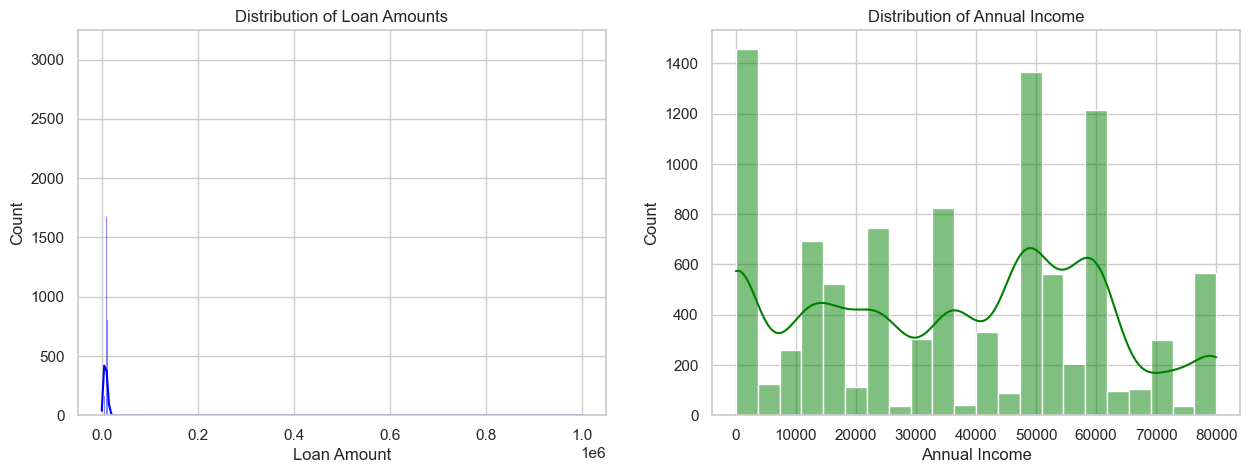

In [7]:
# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# 1. Distribution of Loan Amounts
plt.subplot(1, 2, 1)
sns.histplot(df['loan_amount'], kde=True, color='blue')
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')

# 2. Distribution of Annual Income
plt.subplot(1, 2, 2)
sns.histplot(df['annual_income'], kde=True, color='green')
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')

plt.show()

In [ ]:
# Observation: The loan amounts are concentrated around specific values (e.g., 5000, 7500), suggesting standardized loan products. Annual income shows a right-skew, meaning most borrowers are low-income, with a few high-earners.

/var/folders/2p/dx176pz54kz6bzdn9qq091940000gn/T/ipykernel_6597/208657015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=business_loans.index, y=business_loans.values, palette='viridis')


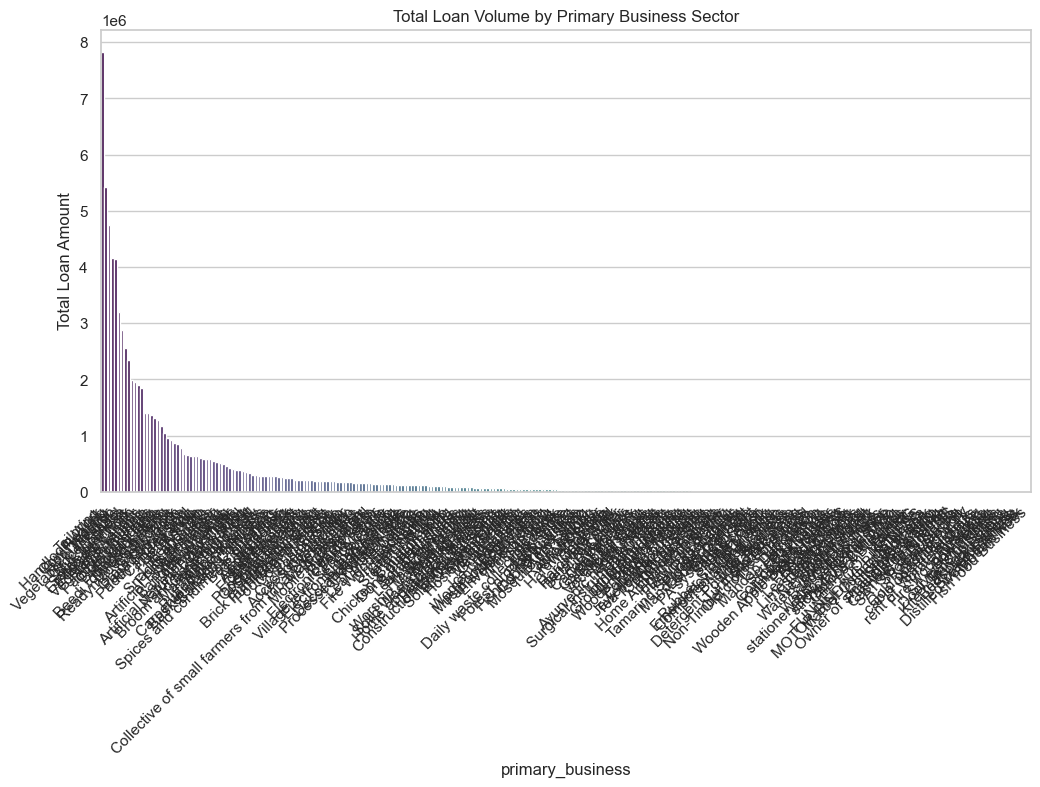

In [8]:
plt.figure(figsize=(12, 6))
# Group by primary business and sum the loan amounts
business_loans = df.groupby('primary_business')['loan_amount'].sum().sort_values(ascending=False)

sns.barplot(x=business_loans.index, y=business_loans.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Total Loan Volume by Primary Business Sector')
plt.ylabel('Total Loan Amount')
plt.show()

In [ ]:
# Observation:  sector has the highest total loan volume.
# Business Insight: The institution is heavily exposed to this sector. To reduce risk, they should diversify their loan portfolio into other emerging rural businesses. 

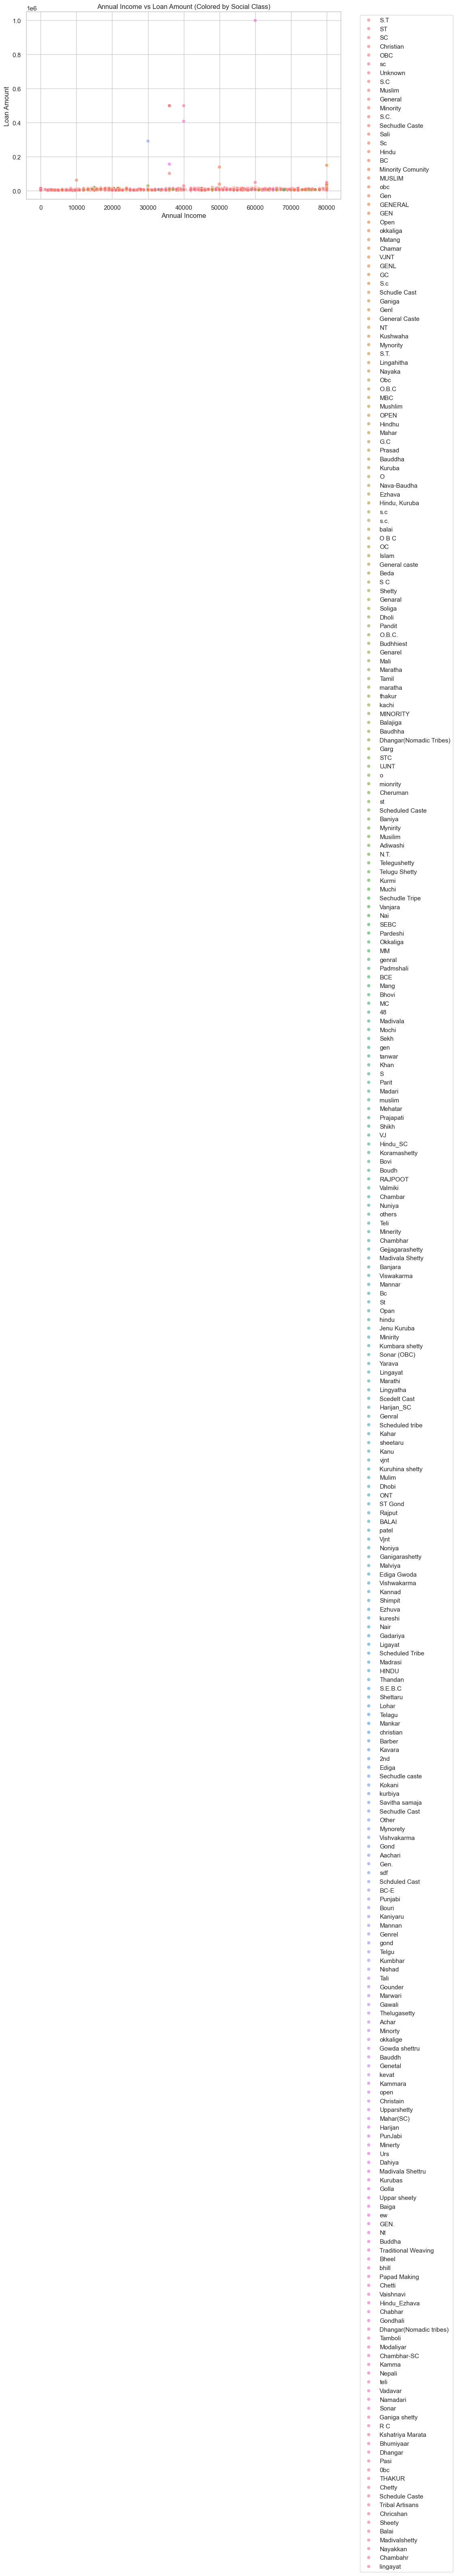

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='annual_income', y='loan_amount', hue='social_class', alpha=0.6)
plt.title('Annual Income vs Loan Amount (Colored by Social Class)')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

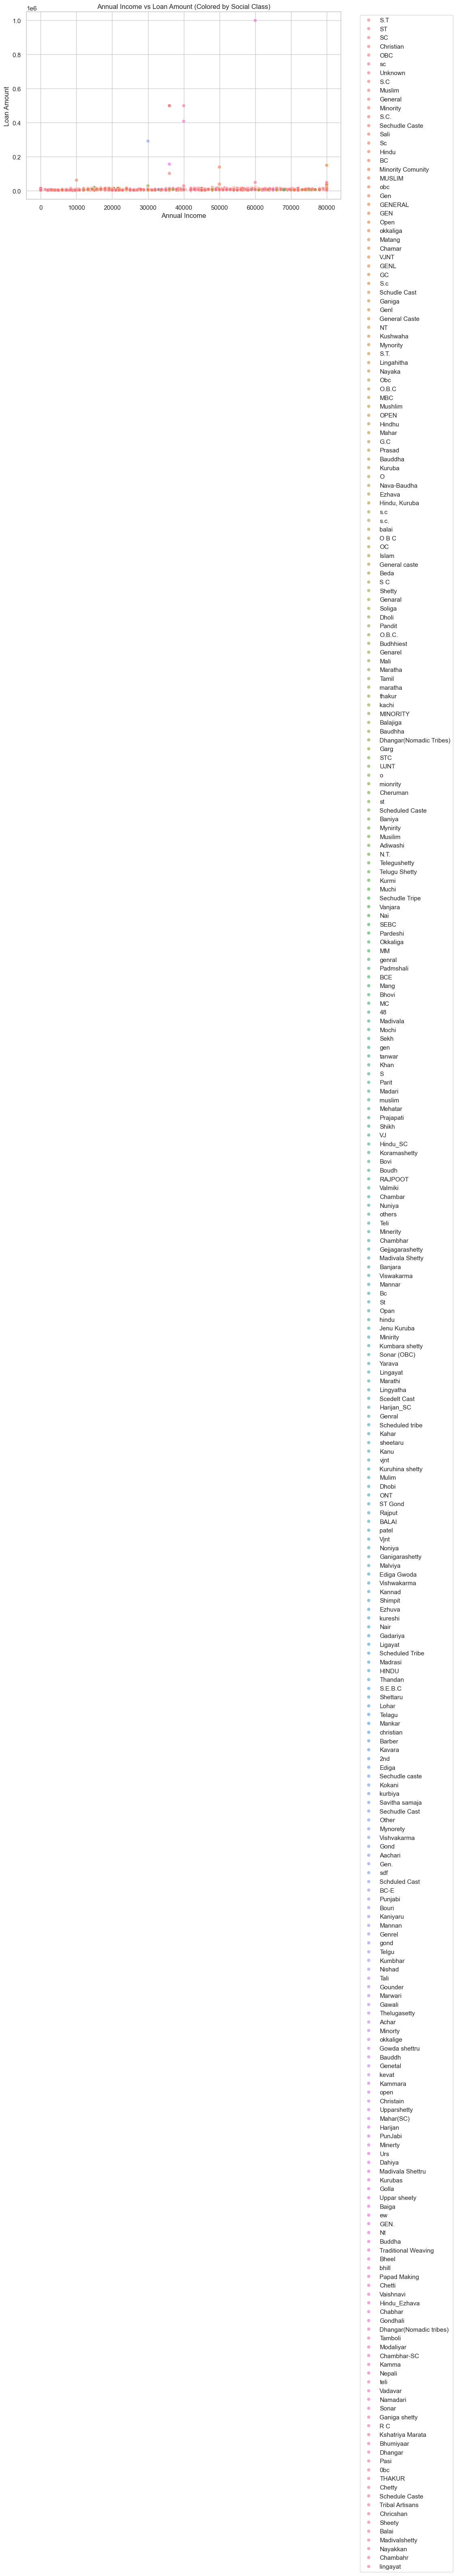

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='annual_income', y='loan_amount', hue='social_class', alpha=0.6)
plt.title('Annual Income vs Loan Amount (Colored by Social Class)')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# Observation: There is a [Weak/Strong] correlation between annual income and loan amount.
# Business Insight: Interestingly, some low-income borrowers are receiving high-value loans. These are "High-Risk" anomalies that require immediate auditing to prevent defaults.

In [11]:
# Descriptive statistics for numerical columns
summary_stats = df[['annual_income', 'monthly_expenses', 'loan_amount', 'disposable_income']].describe()
print(summary_stats)

       annual_income  monthly_expenses     loan_amount  disposable_income
count   10000.000000      10000.000000    10000.000000       1.000000e+04
mean    36366.369500       3780.620400     8434.040000      -9.001075e+03
std     24019.143527       4552.373791    14565.399217       5.744225e+04
min         0.000000          2.000000      100.000000      -2.868000e+06
25%     14400.000000       2600.000000     5000.000000      -3.000000e+04
50%     36000.000000       3500.000000     8000.000000       8.000000e+02
75%     55000.000000       4000.000000    10000.000000       1.200000e+04
max     80000.000000     240000.000000  1000000.000000       6.200000e+04
